In [1]:
import os, sys, subprocess as sbp
import numpy as np
import matplotlib.pyplot as plt
os.environ["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"
try:
    from dmae import DMAP
except:
    sbp.check_call([sys.executable, "-m", "pip", "install", "git+https://github.com/sparsetrace/DMAE.git"])
    from dmae import DMAP
from dmae.cloud import ensure_hf_token, ensure_modal_tokens, ensure_github_netrc

HF_USER  = "jcandane"
HF_TOKEN = ensure_hf_token(required=False)
ensure_modal_tokens(required=False, quiet=False)   # configures modal if secrets exist
ensure_github_netrc(required=False)                # enables pip install from private GH via ~/.netrc

✅ Modal tokens configured.


True

In [3]:
import plotly.graph_objects as go
from sklearn.datasets import make_swiss_roll
import numpy as np
from dmae.GPLM import GPLM
from dmae.DMAP import DMAP

R_iX, color = make_swiss_roll(n_samples=2000, noise=0.0)
R_iX = R_iX.astype(np.float32)

encoder = DMAP(R_iX, d=64, h=1, beta=0.5)

R_ix    = encoder(R_iX) #[:,0,:] # encoder.init_data.ψ_ix * encoder.init_data.λ_x[:, None, :]   # (1, N, 2)  #

decoder = GPLM(R_ix=R_ix, R_iX=R_iX)

Q_iX    = decoder(R_ix)           # (N, 3)

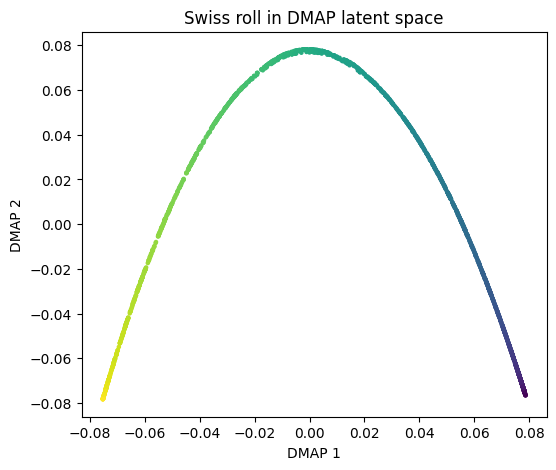

MSE per dim: [0.00148107 0.00514224 0.00053207]
Total MSE: 0.0023851262


In [4]:
plt.figure(figsize=(6, 5))
plt.scatter(R_ix[:, 0, 0], R_ix[:, 0, 1], c=color, s=5)
plt.xlabel("DMAP 1")
plt.ylabel("DMAP 2")
plt.title("Swiss roll in DMAP latent space")
plt.show()

mse_per_dim = np.mean((Q_iX - R_iX) ** 2, axis=0)
print("MSE per dim:", mse_per_dim)
print("Total MSE:", mse_per_dim.mean())

fig = go.Figure()

# Original points: large black rings
fig.add_trace(
    go.Scatter3d(
        x=R_iX[:, 0], y=R_iX[:, 1], z=R_iX[:, 2],
        mode="markers",
        marker=dict(
            size=5,
            color="black",
            opacity=0.35,
            symbol="circle-open",
            line=dict(width=2, color="black"),
        ),
        name="original",
    )
)

# Reconstruction: colored filled discs
fig.add_trace(
    go.Scatter3d(
        x=Q_iX[:, 0], y=Q_iX[:, 1], z=Q_iX[:, 2],
        mode="markers",
        marker=dict(
            size=3,
            color=color,
            colorscale="Viridis",
            opacity=0.95,
            symbol="circle",
        ),
        name="reconstruction",
    )
)

fig.update_layout(
    title=f"Swiss roll: original (black rings) vs GPLM reconstruction (colored discs), MSE={mse_per_dim.mean()}",
    scene=dict(
        xaxis_title="x",
        yaxis_title="y",
        zaxis_title="z",
    ),
    width=950,
    height=750,
)
fig.show()

In [5]:
from sklearn.datasets import make_swiss_roll
import numpy as np
from dmae.DMAE import DMAE

R_iX, color = make_swiss_roll(n_samples=2000, noise=0.0)
R_iX = R_iX.astype(np.float32)

Model = DMAE(R_iX, d=32)

Q_ix = Model.encode(R_iX)   # (N, 1, 32)
Q_iX = Model(Q_ix)          # decode latent -> ambient
# same as:
# Q_iX = Model.decode(Q_ix)

# full reconstruction directly from ambient:
Rhat_iX = Model.reconstruct(R_iX)

mse_per_dim = np.mean((Rhat_iX - R_iX) ** 2, axis=0)
print("MSE per dim:", mse_per_dim)
print("Total MSE:", mse_per_dim.mean())



MSE per dim: [2.4219267e-07 1.0802041e-06 2.3435314e-07]
Total MSE: 5.1891664e-07
